In [1]:
import numpy as np
from bs import Call
import matplotlib.pyplot as plt

In [2]:
tau = 1
K = 10
S = 10
r = 0.0
sigma = 0.2
C = Call(tau, K, S, r, sigma)

In [3]:
C.price

np.float64(0.7965567455405793)

In [4]:
C.price_approx()

np.float64(0.8)

In [5]:
C.delta

np.float64(0.539827837277029)

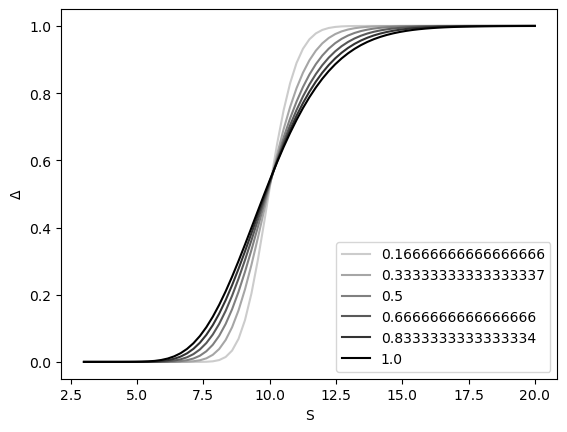

In [6]:
prices = np.linspace(3, 20, 71)
taus = np.linspace(1./6., 1., 6)
gray_colors = ['0.8', '0.65', '0.5', '0.35', '0.2', '0.0']
for i in range(6):
    plt.plot(prices, [Call(taus[i], K, S, r, sigma).delta for S in prices], color=gray_colors[i], label=taus[i])
plt.xlabel('S')
plt.ylabel('$\\Delta$')
plt.legend()
plt.show()

In [7]:
tau1 = 2
tau2 = 0.1
K1 = 10
K2 = 10
Gamma = Call(tau = tau1, K = K1, S = 10, r = 0.05, sigma = 0.8).gamma - Call(tau = tau2, K = K2, S = 10, r = 0.05, sigma = 0.8).gamma
Vega = Call(tau = tau1, K = K1, S = 10, r = 0.05, sigma = 0.8).vega - Call(tau = tau2, K = K2, S = 10, r = 0.05, sigma = 0.8).vega
Gamma, Vega

(np.float64(-0.12754689839295222), np.float64(3.307257226054851))

<h1>Monte Carlo</h1>



In [8]:
r = 0.05
sigma = 0.15
T = 1
nb_MC = 1_000_000
WT_s = np.random.normal(0., np.sqrt(T), nb_MC)
S_0 = 10.
epsilon = 0.01
S_0_modif = S_0 + epsilon
ST_s = S_0 * np.exp((r-sigma**2/2.)*T + sigma * WT_s)
ST_s_modif = S_0_modif * np.exp((r-sigma**2/2.)*T + sigma * WT_s)
K = 10.
m = np.mean(np.exp(-r*T) * np.maximum(ST_s - K, 0.))
m_modif = np.mean(np.exp(-r*T) * np.maximum(ST_s_modif - K, 0.))
delta_malliavin = np.mean(np.exp(-r*T) * WT_s * np.maximum(ST_s - K, 0.) / (S_0 * sigma * T))
s = np.std(np.exp(-r*T) * np.maximum(ST_s - K, 0.))/np.sqrt(nb_MC)
m-3*s, m+3*s, (m_modif - m)/epsilon, delta_malliavin

(np.float64(0.8558510129591607),
 np.float64(0.8625228976348888),
 np.float64(0.6602020638887929),
 np.float64(0.6570963885961625))